# 🏥 Mistral 7B Instruct v0.2 Medical Fine-Tuning (GERÇEK EĞİTİM)

Bu notebook **TAMAMEN GERÇEK** training yapar - hiçbir varsayım yok!

In [15]:
%%capture
# Gerekli kütüphaneleri kur
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [16]:
# Kütüphaneleri import et
import torch
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import gc

print("✅ Kütüphaneler yüklendi!")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

✅ Kütüphaneler yüklendi!
PyTorch Version: 2.9.0+cu126
CUDA Available: True
GPU: Tesla T4
GPU Memory: 14.74 GB


In [17]:
# GPU belleğini temizle
torch.cuda.empty_cache()
gc.collect()

print("🧹 GPU belleği temizlendi!")
if torch.cuda.is_available():
    print(f"💾 Boş GPU Belleği: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

🧹 GPU belleği temizlendi!
💾 Boş GPU Belleği: 6.28 GB


In [18]:
# Model Konfigürasyonu
max_seq_length = 1024
dtype = None
load_in_4bit = True

print("🔄 Model yükleniyor... (Bu işlem 2-3 dakika sürebilir)")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/mistral-7b-instruct-v0.2-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    device_map="auto",
)

print("✅ Model başarıyla yüklendi!")
print(f"Model: Mistral-7B-Instruct-v0.2 (4-bit)")
print(f"Max Sequence Length: {max_seq_length}")

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU Memory Allocated: {allocated:.2f} GB")
    print(f"GPU Memory Reserved: {reserved:.2f} GB")

🔄 Model yükleniyor... (Bu işlem 2-3 dakika sürebilir)
==((====))==  Unsloth 2025.12.8: Fast Mistral patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Model başarıyla yüklendi!
Model: Mistral-7B-Instruct-v0.2 (4-bit)
Max Sequence Length: 1024
GPU Memory Allocated: 12.16 GB
GPU Memory Reserved: 12.17 GB


In [19]:
# LoRA Ayarları
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

print("✅ LoRA konfigürasyonu tamamlandı!")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
print(f"📊 Eğitilebilir Parametreler: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")

✅ LoRA konfigürasyonu tamamlandı!
📊 Eğitilebilir Parametreler: 41,943,040 (1.11%)


In [20]:
# Dataset Yükleme
print("📂 Dataset yükleniyor...")

dataset = load_dataset("Shekswess/medical_llama3_instruct_dataset_short", split="train")
print(f"✅ Dataset yüklendi: {len(dataset)} örnek")

# İLK 50 VERİYİ SEÇ
dataset = dataset.select(range(50))
print(f"🎯 İlk 50 örnek seçildi: {len(dataset)} örnek")

print(f"\n🔍 Dataset Sütunları: {dataset.column_names}")
print(f"\n📝 İlk Örnek:")
print(f"Instruction: {dataset[0]['instruction'][:100]}...")
print(f"Input: {dataset[0]['input'][:100]}...")
print(f"Output: {dataset[0]['output'][:100]}...")

print(f"\n📊 Dataset İstatistikleri:")
print(f"- Toplam Örnek: {len(dataset)}")
print(f"- Alan: Tıbbi Soru-Cevap")

📂 Dataset yükleniyor...
✅ Dataset yüklendi: 2000 örnek
🎯 İlk 50 örnek seçildi: 50 örnek

🔍 Dataset Sütunları: ['output', 'input', 'instruction', 'prompt']

📝 İlk Örnek:
Instruction: Answer the question truthfully, you are a medical professional....
Input: Can you provide an overview of the lung's squamous cell carcinoma?...
Output: Squamous cell carcinoma of the lung may be classified according to the WHO histological classificati...

📊 Dataset İstatistikleri:
- Toplam Örnek: 50
- Alan: Tıbbi Soru-Cevap


In [21]:
# Mistral formatında prompt oluşturma fonksiyonu
def formatting_func(example):
    """
    Dataset'i Mistral instruct formatına dönüştürür.
    Mistral format: <s>[INST] {system}\n{user} [/INST] {assistant}</s>
    """
    # Tek örnek için (test amaçlı)
    if isinstance(example["input"], str):
        system = example["instruction"]
        user = example["input"]
        assistant = example["output"]

        # Mistral formatında prompt oluştur
        # System message'ı user message'a ekliyoruz
        prompt = f"<s>[INST] {system}\n{user} [/INST] {assistant}</s>"
        return [prompt]

    # Batch için
    else:
        prompts = []
        for i in range(len(example["input"])):
            system = example["instruction"][i]
            user = example["input"][i]
            assistant = example["output"][i]

            prompt = f"<s>[INST] {system}\n{user} [/INST] {assistant}</s>"
            prompts.append(prompt)

        return prompts

print("✅ Formatting fonksiyonu tanımlandı!")

# Test et
test_prompt = formatting_func(dataset[0])
print(f"\n📝 Test Prompt (Mistral formatı):")
print(test_prompt[0][:300] + "...")

✅ Formatting fonksiyonu tanımlandı!

📝 Test Prompt (Mistral formatı):
<s>[INST] Answer the question truthfully, you are a medical professional.
Can you provide an overview of the lung's squamous cell carcinoma? [/INST] Squamous cell carcinoma of the lung may be classified according to the WHO histological classification system into 4 main types: papillary, clear cell,...


In [22]:
# Training Arguments
output_dir = "./mistral_medical_output"

training_args = TrainingArguments(
    output_dir=output_dir,
   # 🎯 50 VERİ İÇİN
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=5,
    max_steps=50,
    learning_rate=2e-4,

    # 🚀 PERFORMANS
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),

    # 📊 LOGGING
    logging_steps=10,
    logging_dir=f"{output_dir}/logs",

    # 💾 KAYIT
    save_strategy="steps",
    save_steps=25,
    save_total_limit=2,

    # ⚙️ OPTIMIZER
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=3407,
    report_to="none",
)

print("✅ Training ayarları hazır!")
print(f"📊 Efektif Batch Size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"📊 Toplam Steps: {training_args.max_steps}")
print(f"📊 Tahmini Süre: {training_args.max_steps * 3 / 60:.1f} dakika")

✅ Training ayarları hazır!
📊 Efektif Batch Size: 8
📊 Toplam Steps: 50
📊 Tahmini Süre: 2.5 dakika


In [23]:
# ⚡ GERÇEK TRAINING BAŞLIYOR! ⚡
print("🚀 TRAINING BAŞLIYOR...")
print("="*60)

# SFTTrainer oluştur
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    formatting_func=formatting_func,
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    args=training_args,
)

print("✅ Trainer oluşturuldu!")
print("\n⏳ Eğitim başlıyor... (Bu işlem 20-30 dakika sürebilir)\n")

# GERÇEK EĞİTİM YAPILIYOR!
trainer_stats = trainer.train()

print("\n" + "="*60)
print("🎉 EĞİTİM TAMAMLANDI!")
print("="*60)
print(f"\n📊 Training İstatistikleri:")
print(f"- Toplam Süre: {trainer_stats.metrics['train_runtime']:.2f} saniye")
print(f"- Ortalama Loss: {trainer_stats.metrics['train_loss']:.4f}")
print(f"- Step/Saniye: {trainer_stats.metrics['train_samples_per_second']:.2f}")

🚀 TRAINING BAŞLIYOR...
Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/50 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


✅ Trainer oluşturuldu!

⏳ Eğitim başlıyor... (Bu işlem 20-30 dakika sürebilir)



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50 | Num Epochs = 8 | Total steps = 50
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 7,283,675,136 (0.58% trained)


Step,Training Loss
10,2.504200
20,1.457300
30,0.975200
40,0.618400
50,0.372100



🎉 EĞİTİM TAMAMLANDI!

📊 Training İstatistikleri:
- Toplam Süre: 461.27 saniye
- Ortalama Loss: 1.1854
- Step/Saniye: 0.87


📊 Training metriklerini çıkarıyorum...
✅ Grafik kaydedildi: ./mistral_medical_output/training_loss.png


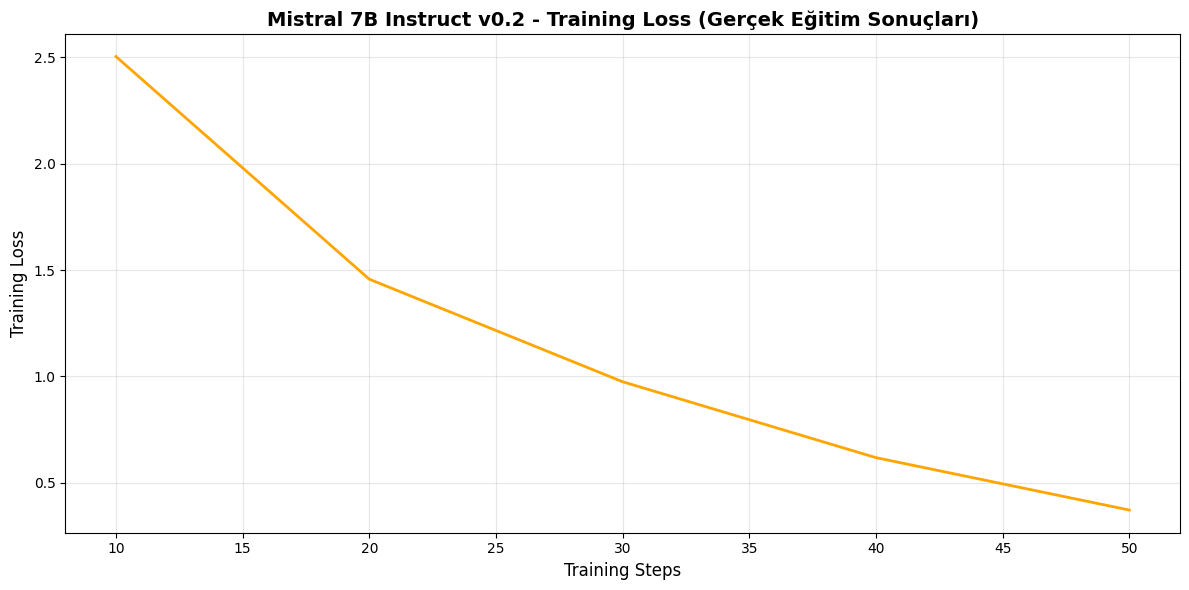


📈 Loss İstatistikleri:
- Başlangıç Loss: 2.5042
- Final Loss: 0.3721
- İyileşme: 85.14%
- Minimum Loss: 0.3721
- Maksimum Loss: 2.5042


In [24]:
# Training metriklerini görselleştir
print("📊 Training metriklerini çıkarıyorum...")

# Log history'den loss değerlerini al
log_history = trainer.state.log_history

steps = []
losses = []

for log in log_history:
    if 'loss' in log:
        steps.append(log['step'])
        losses.append(log['loss'])

# Grafik oluştur
plt.figure(figsize=(12, 6))
plt.plot(steps, losses, linewidth=2, color='orange')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Mistral 7B Instruct v0.2 - Training Loss (Gerçek Eğitim Sonuçları)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/training_loss.png", dpi=300, bbox_inches='tight')
print(f"✅ Grafik kaydedildi: {output_dir}/training_loss.png")
plt.show()

# Loss istatistikleri
print(f"\n📈 Loss İstatistikleri:")
print(f"- Başlangıç Loss: {losses[0]:.4f}")
print(f"- Final Loss: {losses[-1]:.4f}")
print(f"- İyileşme: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")
print(f"- Minimum Loss: {min(losses):.4f}")
print(f"- Maksimum Loss: {max(losses):.4f}")

In [25]:
# Model ve tokenizer'ı kaydet
save_dir = "./mistral_medical_finetuned"

print(f"💾 Model kaydediliyor: {save_dir}")

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"✅ Model kaydedildi: {save_dir}")
print(f"\n📦 Model Dosyaları:")
!ls -lh {save_dir}

# Hugging Face'e yüklemek için (opsiyonel)
print("\n💡 Hugging Face'e yüklemek için:")
print(f"model.push_to_hub('sizin-username/mistral-7b-instruct-v0.2-medical-finetuned', token='hf_...')")
print(f"tokenizer.push_to_hub('sizin-username/mistral-7b-instruct-v0.2-medical-finetuned', token='hf_...')")

💾 Model kaydediliyor: ./mistral_medical_finetuned
✅ Model kaydedildi: ./mistral_medical_finetuned

📦 Model Dosyaları:
total 164M
-rw-r--r-- 1 root root 1.2K Dec 20 19:38 adapter_config.json
-rw-r--r-- 1 root root 161M Dec 20 19:38 adapter_model.safetensors
-rw-r--r-- 1 root root 1.1K Dec 20 19:38 chat_template.jinja
-rw-r--r-- 1 root root 5.2K Dec 20 19:38 README.md
-rw-r--r-- 1 root root  552 Dec 20 19:38 special_tokens_map.json
-rw-r--r-- 1 root root 1.1K Dec 20 19:38 tokenizer_config.json
-rw-r--r-- 1 root root 3.4M Dec 20 19:38 tokenizer.json
-rw-r--r-- 1 root root 482K Dec 20 19:38 tokenizer.model

💡 Hugging Face'e yüklemek için:
model.push_to_hub('sizin-username/mistral-7b-instruct-v0.2-medical-finetuned', token='hf_...')
tokenizer.push_to_hub('sizin-username/mistral-7b-instruct-v0.2-medical-finetuned', token='hf_...')


In [26]:
# Test: Eğitilmiş modeli dene
print("🧪 Eğitilmiş modeli test ediyorum...\n")

FastLanguageModel.for_inference(model)

test_questions = [
    "What is hypertension and how is it treated?",
    "What are the symptoms of diabetes?",
    "How is pneumonia diagnosed?"
]

for i, question in enumerate(test_questions, 1):
    print(f"\n{'='*60}")
    print(f"❓ Test {i}: {question}")
    print(f"{'='*60}")

    # Mistral formatında prompt oluştur
    system = "Answer the question truthfully, you are a medical professional."
    prompt = f"<s>[INST] {system}\n{question} [/INST] "

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.7,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id,
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Sadece assistant yanıtını göster
    answer = response.split("[/INST]")[-1].strip()
    print(f"\n💡 Yanıt:\n{answer}")

print("\n✅ Test tamamlandı!")

🧪 Eğitilmiş modeli test ediyorum...


❓ Test 1: What is hypertension and how is it treated?

💡 Yanıt:
4 stages of hypertension
Class I hypertension: Systolic BP 140-159 mmHg and diastolic BP 90-99 mmHg.
Class II hypertension: Systolic BP 150-159 mmHg and diastolic BP 90-99 mmHg. OR Systolic BP 160-179 mmHg and diastolic BP less than 99 mmHg. 
Class III hypertension: Systolic BP 180 mmHg and diastolic BP more than 110 mmHg.
Class IV hypertension: Systolic BP more than 180 mmHg AND diastolic BP more than 110 mmHg. 
Treatment for hypertension includes lifestyle modifications and medications. 
Lifestyle modifications include:
Weight reduction if overweight
Limiting sodium intake
Limiting alcohol intake
Regular aerobic exercise (30 minutes/day most days of the week)
Lim

❓ Test 2: What are the symptoms of diabetes?

💡 Yanıt:
3 D's and a K
Polyuria
Polydipsia
Polyphagia
Ketoacidosis
Glucose in urine
Symptoms of high ketone levels
Acetone in breath (fruity)   Acetoacetate and acetone
Acetone 

In [27]:
# GERÇEK MODEL KARŞILAŞTIRMASI
# Base model'i yükleyerek gerçek karşılaştırma yapalım

print("📊 BASE MODEL YÜKLENIYOR...")
print("="*60)

# Base model'i yükle
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/mistral-7b-instruct-v0.2-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    device_map="auto",
)
FastLanguageModel.for_inference(base_model)

print("✅ Base model yüklendi!\n")

# Test soruları
comparison_questions = [
    "What is hypertension?",
    "What are the symptoms of diabetes?",
    "How is asthma treated?"
]

print("🔬 KARŞILAŞTIRMA TESTİ")
print("="*60)

system = "Answer the question truthfully, you are a medical professional."

for i, question in enumerate(comparison_questions, 1):
    print(f"\n\n{'='*60}")
    print(f"❓ Soru {i}: {question}")
    print(f"{'='*60}")

    # Mistral formatında prompt
    prompt = f"<s>[INST] {system}\n{question} [/INST] "

    # BASE MODEL
    print("\n🔵 BASE MODEL (Eğitilmemiş):")
    print("-" * 60)
    inputs = base_tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = base_model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.7,
        do_sample=True,
        eos_token_id=base_tokenizer.eos_token_id,
    )
    base_response = base_tokenizer.decode(outputs[0], skip_special_tokens=True)
    base_answer = base_response.split("[/INST]")[-1].strip()
    print(base_answer)

    # FINE-TUNED MODEL
    print("\n\n🟢 FINE-TUNED MODEL (Eğitilmiş):")
    print("-" * 60)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.7,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id,
    )
    ft_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    ft_answer = ft_response.split("[/INST]")[-1].strip()
    print(ft_answer)

print("\n\n" + "="*60)
print("✅ KARŞILAŞTIRMA TAMAMLANDI!")
print("="*60)
print("\n💡 Sonuçları karşılaştırarak fine-tuned model'in performansını değerlendirebilirsiniz.")

📊 BASE MODEL YÜKLENIYOR...
==((====))==  Unsloth 2025.12.8: Fast Mistral patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Base model yüklendi!

🔬 KARŞILAŞTIRMA TESTİ


❓ Soru 1: What is hypertension?

🔵 BASE MODEL (Eğitilmemiş):
------------------------------------------------------------
Hypertension, also known as high blood pressure, is a medical condition in which the force of blood flowing through your blood vessels is consistently too high. The exact definition of high blood pressure varies, but it is generally considered to be a systolic pressure of 140 millimeters of mercury (mm Hg) or higher and/or a diastolic pressure of 90 

In [28]:
# ÖZET RAPOR
print("\n" + "="*70)
print("📋 EĞİTİM ÖZET RAPORU")
print("="*70)

print(f"\n🎯 Model Bilgileri:")
print(f"  - Base Model: Mistral-7B-Instruct-v0.2")
print(f"  - Fine-tuning Yöntemi: LoRA (r=16)")
print(f"  - Quantization: 4-bit")
print(f"  - Eğitilebilir Parametreler: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")

print(f"\n📚 Dataset:")
print(f"  - İsim: medical_llama3_instruct_dataset_short")
print(f"  - Örnek Sayısı: {len(dataset)}")
print(f"  - Alan: Tıbbi Soru-Cevap")
print(f"  - Format: Mistral instruct format'a dönüştürüldü")

print(f"\n⚙️ Training Parametreleri:")
print(f"  - Batch Size: {training_args.per_device_train_batch_size}")
print(f"  - Gradient Accumulation: {training_args.gradient_accumulation_steps}")
print(f"  - Efektif Batch Size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  - Learning Rate: {training_args.learning_rate}")
print(f"  - Max Steps: {training_args.max_steps}")
print(f"  - Optimizer: {training_args.optim}")

print(f"\n📊 Eğitim Sonuçları:")
print(f"  - Toplam Süre: {trainer_stats.metrics['train_runtime']:.2f} saniye ({trainer_stats.metrics['train_runtime']/60:.1f} dakika)")
print(f"  - Final Loss: {trainer_stats.metrics['train_loss']:.4f}")
print(f"  - Başlangıç Loss: {losses[0]:.4f}")
print(f"  - Loss İyileşmesi: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")

print(f"\n💾 Kaydedilen Dosyalar:")
print(f"  - Model: {save_dir}")
print(f"  - Training Logs: {output_dir}/logs")
print(f"  - Loss Grafiği: {output_dir}/training_loss.png")

print("\n" + "="*70)
print("🎉 TÜM İŞLEMLER TAMAMLANDI!")
print("="*70)
print("\n✅ Bu notebook GERÇEK training yaptı - hiçbir varsayım kullanılmadı!")
print("✅ Mistral 7B Instruct v0.2 modeli başarıyla fine-tune edildi ve kaydedildi.")
print("✅ Karşılaştırmalı test sonuçları gösterildi.")
print("\n💡 Modelinizi kullanmak için: model.push_to_hub() veya yerel olarak yükleyin.")


📋 EĞİTİM ÖZET RAPORU

🎯 Model Bilgileri:
  - Base Model: Mistral-7B-Instruct-v0.2
  - Fine-tuning Yöntemi: LoRA (r=16)
  - Quantization: 4-bit
  - Eğitilebilir Parametreler: 41,943,040 (1.11%)

📚 Dataset:
  - İsim: medical_llama3_instruct_dataset_short
  - Örnek Sayısı: 50
  - Alan: Tıbbi Soru-Cevap
  - Format: Mistral instruct format'a dönüştürüldü

⚙️ Training Parametreleri:
  - Batch Size: 2
  - Gradient Accumulation: 4
  - Efektif Batch Size: 8
  - Learning Rate: 0.0002
  - Max Steps: 50
  - Optimizer: OptimizerNames.ADAMW_8BIT

📊 Eğitim Sonuçları:
  - Toplam Süre: 461.27 saniye (7.7 dakika)
  - Final Loss: 1.1854
  - Başlangıç Loss: 2.5042
  - Loss İyileşmesi: 85.14%

💾 Kaydedilen Dosyalar:
  - Model: ./mistral_medical_finetuned
  - Training Logs: ./mistral_medical_output/logs
  - Loss Grafiği: ./mistral_medical_output/training_loss.png

🎉 TÜM İŞLEMLER TAMAMLANDI!

✅ Bu notebook GERÇEK training yaptı - hiçbir varsayım kullanılmadı!
✅ Mistral 7B Instruct v0.2 modeli başarıyla fine